## A convolutional neural network that can distinguish between pictures of horses and pictures of humans 

In [1]:
!wget \
  https://storage.googleapis.com/learning-datasets/horse-or-human.zip \
  -O /tmp/horse-or-human.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os
import zipfile
 
local_zip = '/tmp/horse-or-human.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp/horse-or-human')
zip_ref.close()

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/horse-or-human.zip'

In [3]:
import os
import urllib.request
import zipfile

url = "https://storage.googleapis.com/learning-datasets/horse-or-human.zip"

# Saves into a "data" folder next to your notebook
base_dir = os.path.join(os.getcwd(), "data")
os.makedirs(base_dir, exist_ok=True)

local_zip = os.path.join(base_dir, "horse-or-human.zip")
extract_dir = os.path.join(base_dir, "horse-or-human")

# Download
if not os.path.exists(local_zip):
    print("Downloading...")
    urllib.request.urlretrieve(url, local_zip)
    print("Done.")

# Extract
with zipfile.ZipFile(local_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.listdir(extract_dir))

Downloading...
Done.
['horses', 'humans']


In [4]:
import os
import urllib.request
import zipfile

# ---------- Section 2: Download and extract ----------
url = "https://storage.googleapis.com/learning-datasets/horse-or-human.zip"

base_dir = os.path.join(os.getcwd(), "data")
os.makedirs(base_dir, exist_ok=True)

local_zip = os.path.join(base_dir, "horse-or-human.zip")
extract_dir = os.path.join(base_dir, "horse-or-human")

if not os.path.exists(local_zip):
    print("Downloading...")
    urllib.request.urlretrieve(url, local_zip)
    print("Done.")

with zipfile.ZipFile(local_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

# ---------- Section 3: Define directories ----------
# Directory with our training horse pictures
train_horse_dir = os.path.join(extract_dir, "horses")

# Directory with our training human pictures
train_human_dir = os.path.join(extract_dir, "humans")

# Look at some filenames
train_horse_names = os.listdir(train_horse_dir)
print(train_horse_names[:10])

train_human_names = os.listdir(train_human_dir)
print(train_human_names[:10])

# Count the images
print('total training horse images:', len(os.listdir(train_horse_dir)))
print('total training human images:', len(os.listdir(train_human_dir)))

['horse01-0.png', 'horse01-1.png', 'horse01-2.png', 'horse01-3.png', 'horse01-4.png', 'horse01-5.png', 'horse01-6.png', 'horse01-7.png', 'horse01-8.png', 'horse01-9.png']
['human01-00.png', 'human01-01.png', 'human01-02.png', 'human01-03.png', 'human01-04.png', 'human01-05.png', 'human01-06.png', 'human01-07.png', 'human01-08.png', 'human01-09.png']
total training horse images: 500
total training human images: 527


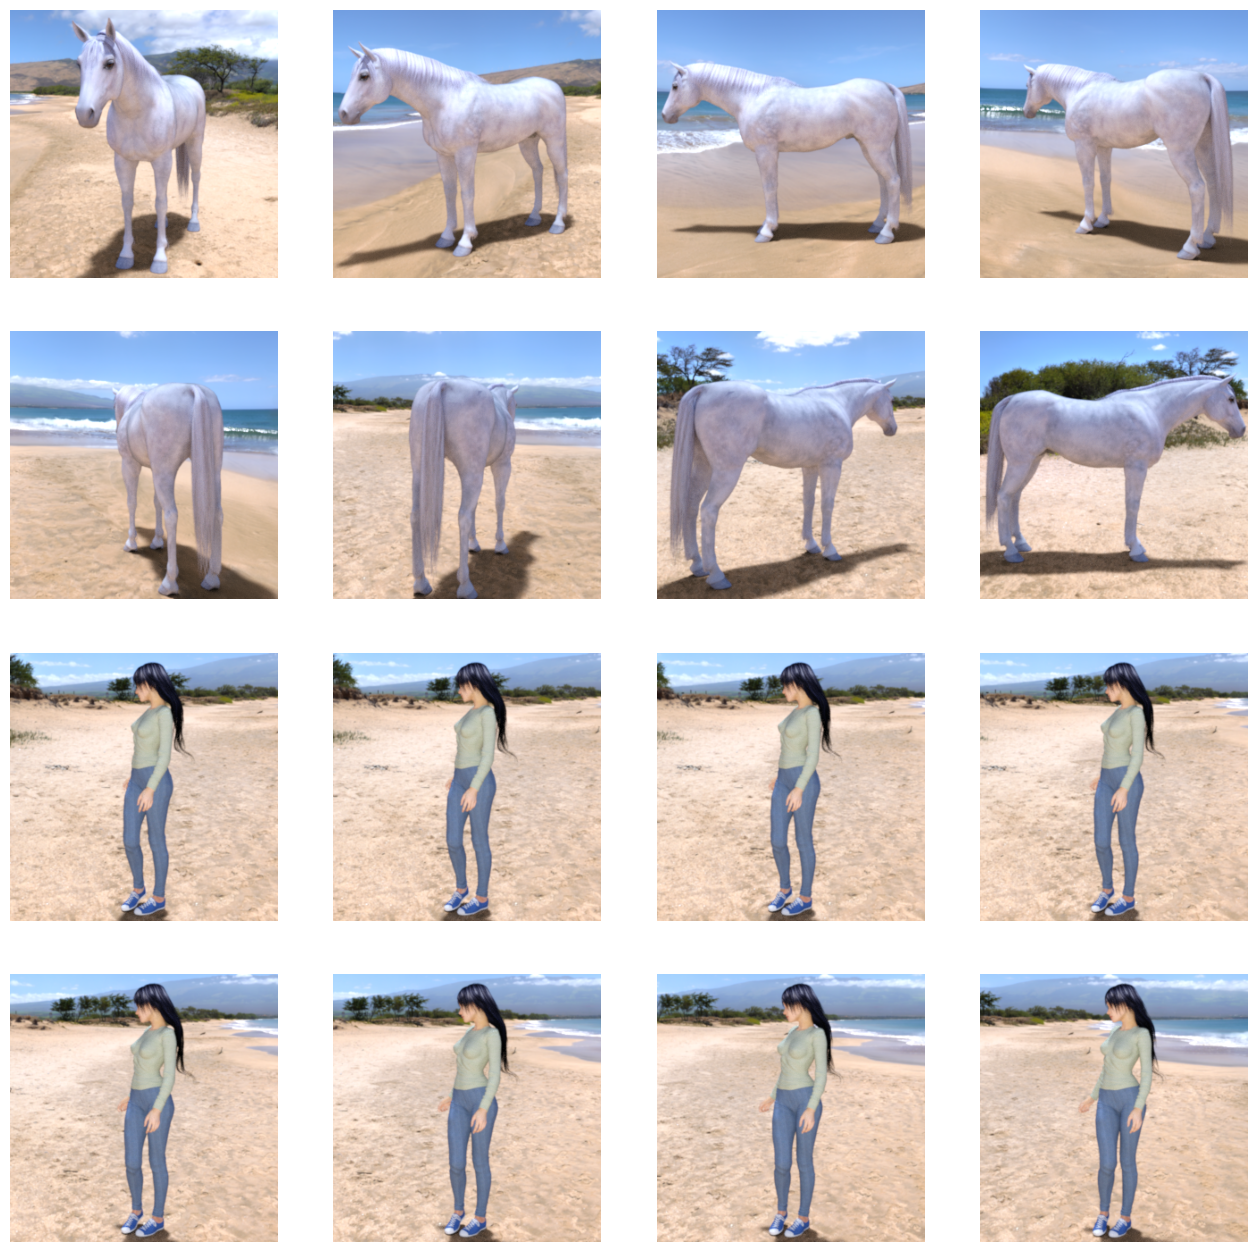

In [5]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Grid of 4 rows x 4 columns = 16 images (8 horses + 8 humans)
nrows = 4
ncols = 4

# Index for iterating over images (increases by 8 each time you rerun)
pic_index = 0

# Set up the figure and size it to fit the 4x4 grid
fig = plt.gcf()
fig.set_size_inches(ncols * 4, nrows * 4)

pic_index += 8

# Full paths of the next 8 horse and 8 human images
next_horse_pix = [os.path.join(train_horse_dir, fname)
                  for fname in train_horse_names[pic_index-8:pic_index]]
next_human_pix = [os.path.join(train_human_dir, fname)
                  for fname in train_human_names[pic_index-8:pic_index]]

for i, img_path in enumerate(next_horse_pix + next_human_pix):
    sp = plt.subplot(nrows, ncols, i + 1)  # subplot indices start at 1
    sp.axis('Off')                          # hide axes and gridlines

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

## Define the model 

In [6]:
import tensorflow as tf

In [7]:
model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 300x300 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(300, 300, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fifth convolution
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),
    # 512 neuron hidden layer
    tf.keras.layers.Dense(512, activation='relu'),
    # Only 1 output neuron. It will contain a value from 0-1 where 0 for 1 class ('horses') and 1 for the other ('humans')
    tf.keras.layers.Dense(1, activation='sigmoid')
])

C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 298, 298, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 149, 149, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 147, 147, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 73, 73, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 71, 71, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 35, 35, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 33, 33, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,606,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,704,097 (6.50 MB)

 Trainable params: 1,704,097 (6.50 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.optimizers import RMSprop
 
model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(lr=0.001),
              metrics=['acc'])

ValueError: Argument(s) not recognized: {'lr': 0.001}

### updated code (renamed argument - changed lr to learning rate)

In [10]:
from tensorflow.keras.optimizers import RMSprop

model.compile(loss='binary_crossentropy',
              optimizer=RMSprop(learning_rate=0.001),
              metrics=['acc'])

## train the model 

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
 
# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
 
# Flow training images in batches of 128 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        '/tmp/horse-or-human/',  # This is the source directory for training images
        target_size=(300, 300),  # All images will be resized to 150x150
        batch_size=128,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

FileNotFoundError: [WinError 3] The system cannot find the path specified: '/tmp/horse-or-human/'

### training with generator (updated pathway to solve error) 

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 128 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
    extract_dir,             # parent folder that contains "horses" and "humans"
    target_size=(300, 300),  # all images are resized to 300x300
    batch_size=128,
    class_mode='binary')     # binary labels for binary_crossentropy

print(train_generator.class_indices)

Found 1027 images belonging to 2 classes.
{'horses': 0, 'humans': 1}


### train 

In [13]:
history = model.fit(
      train_generator,
      steps_per_epoch=8,  
      epochs=15,
      verbose=1)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - acc: 0.5284 - loss: 0.6812
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - acc: 0.5391 - loss: 0.8157


C:\Users\Asus\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - acc: 0.6552 - loss: 0.9516
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7812 - loss: 0.6018
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - acc: 0.8076 - loss: 0.5169
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.6953 - loss: 0.5832
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - acc: 0.7519 - loss: 0.5556
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9219 - loss: 0.3515
Epoch 9/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - acc: 0.8832 - loss: 0.3032
Epoch 10/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9531 - loss: 0.1335
Epoch 11/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - acc: 0.8065 - loss: 0.7212
Epoch 12/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.8750 - loss: 0.3286
Epoch 13/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - acc: 0.9488 - loss: 0.1381
Epoch 14/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - acc: 0.9688 - loss: 0.0776
Epoch 15/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - acc: 0.9399 - loss

## TEst

human16-17.png: score = 0.985
human16-17.png is a human



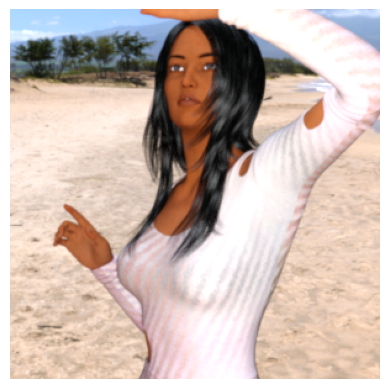

In [14]:
import numpy as np
import tkinter as tk
from tkinter import filedialog
from tensorflow.keras.utils import load_img, img_to_array

# Open a file picker (select one or more images)
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)   # keeps the dialog in front of your browser
file_paths = filedialog.askopenfilenames(
    title="Choose images to test",
    filetypes=[("Images", "*.jpg *.jpeg *.png")]
)
root.destroy()

for path in file_paths:
    fn = os.path.basename(path)

    # Load and resize to what the model expects
    img = load_img(path, target_size=(300, 300))
    x = img_to_array(img)
    x = x / 255.0                      # same normalization as training
    x = np.expand_dims(x, axis=0)      # shape (1, 300, 300, 3)

    prediction = model.predict(x, verbose=0)[0][0]
    print(f"{fn}: score = {prediction:.3f}")

    if prediction > 0.5:
        print(fn + " is a human\n")
    else:
        print(fn + " is a horse\n")

    plt.imshow(img)
    plt.axis('off')
    plt.show()

Using: human10-19.png


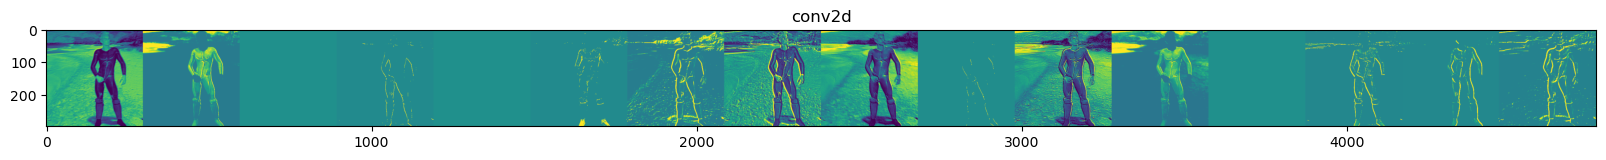

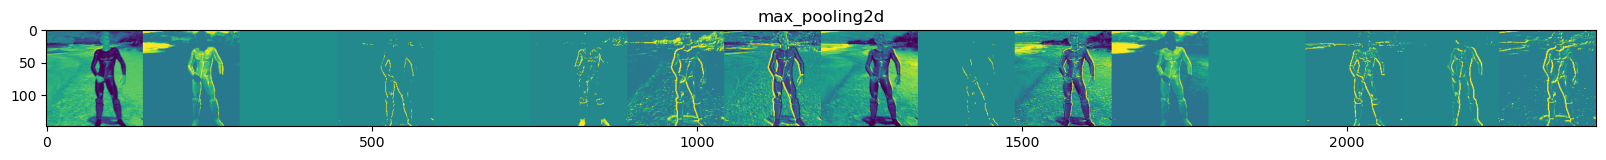

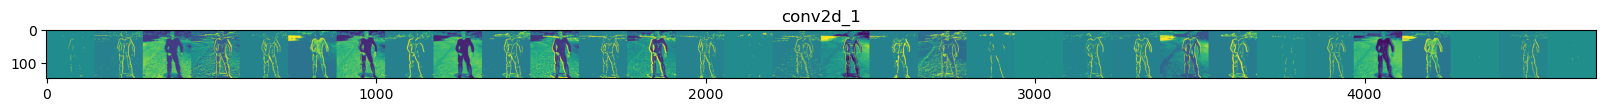

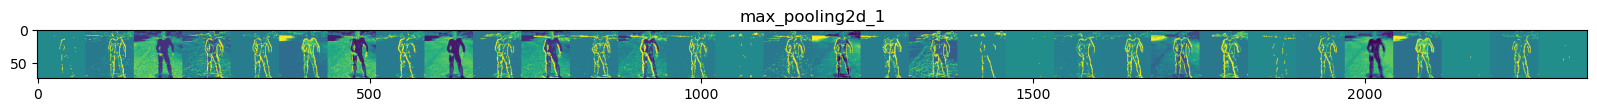

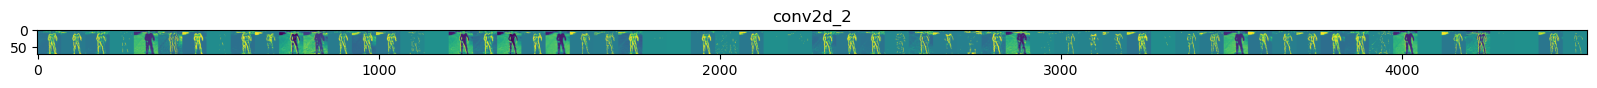

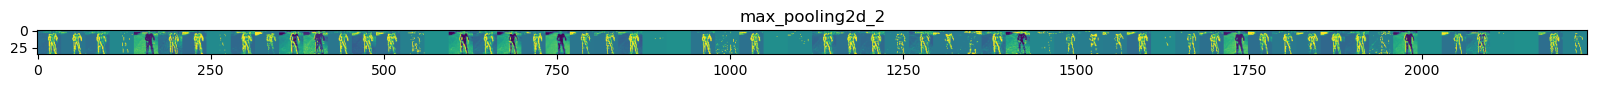

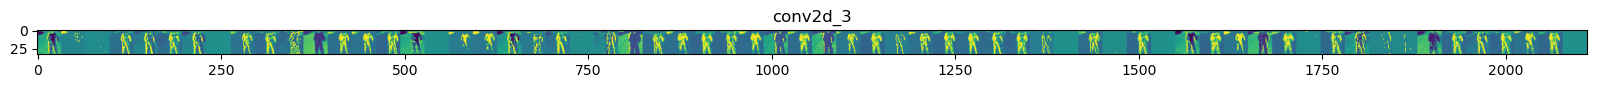

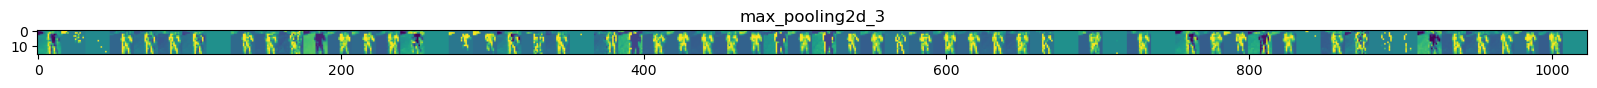

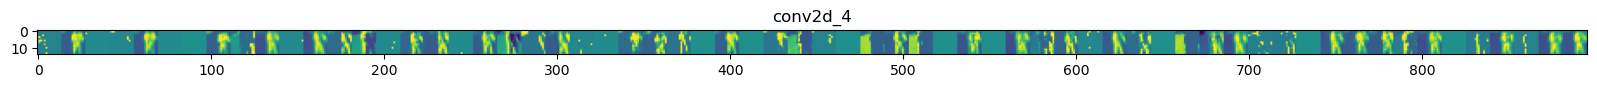

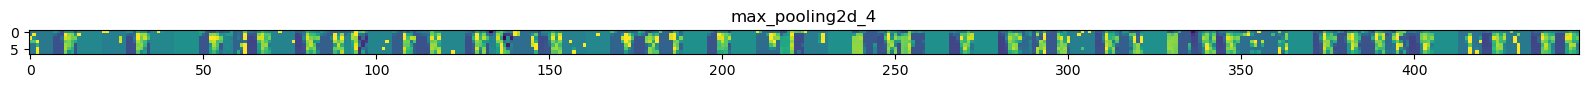

In [15]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.utils import img_to_array, load_img

# New model: same input as our trained model, but outputs every layer's result
successive_outputs = [layer.output for layer in model.layers]
visualization_model = Model(inputs=model.inputs, outputs=successive_outputs)

# Pick a random image from the training set
horse_img_files = [os.path.join(train_horse_dir, f) for f in train_horse_names]
human_img_files = [os.path.join(train_human_dir, f) for f in train_human_names]
img_path = random.choice(horse_img_files + human_img_files)
print("Using:", os.path.basename(img_path))

img = load_img(img_path, target_size=(300, 300))
x = img_to_array(img)              # shape (300, 300, 3)
x = np.expand_dims(x, axis=0)      # shape (1, 300, 300, 3)
x = x / 255.0                      # same rescaling as training

# Run the image through the network and collect every layer's output
successive_feature_maps = visualization_model.predict(x, verbose=0)

layer_names = [layer.name for layer in model.layers]

for layer_name, feature_map in zip(layer_names, successive_feature_maps):
    if len(feature_map.shape) == 4:    # only conv / pooling layers
        n_features = feature_map.shape[-1]
        size = feature_map.shape[1]

        display_grid = np.zeros((size, size * n_features))
        for i in range(n_features):
            f = feature_map[0, :, :, i].copy()
            f -= f.mean()
            if f.std() > 0:
                f /= f.std()
            f *= 64
            f += 128
            f = np.clip(f, 0, 255).astype('uint8')
            display_grid[:, i * size:(i + 1) * size] = f

        scale = 20. / n_features
        plt.figure(figsize=(scale * n_features, scale))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')
        plt.show()